In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

L = 100 #number of lattice points in each dimension
size = L*L*L #total number of lattice points
J = 1.0  #Coupling Coefficient

N = 10 #number of monte-carlo steps for data collection
Neq = 0 #number of MCS for equilibration

Nt = 20 #number of temperatures sampled
Temps = np.logspace(-2,1.5,Nt)

#Data Collection
M_t = np.zeros(N) #magnetization
E_t = np.zeros(N) #energy per spin/lattice point
E2_t = np.zeros(N) #E^2 per spin
s_T = []
M_T = np.zeros(Nt)
E_T = np.zeros(Nt)
Cv_T = np.zeros(Nt)

#Iterate over Temps
Tcounter = 0
for T in Temps:
    #Begin in Random Initial State
    state = np.random.choice([-1,1],(L,L,L))
    state_i = state.copy()
    #Begin Iteration of MCS (monte-carlo steps)
    for n_out in range(N+Neq):
        if n_out >= Neq:
            #compute and store magnetization
            M_t[n_out-Neq] = np.sum(state)/size
            #compute and store energy per spin
            E_t[n_out-Neq] = -J*np.sum(state*(np.roll(state,1,0)+np.roll(state,1,1)+np.roll(state,1,2)))/size
            #compute and store E^2 per spin
            E2_t[n_out-Neq] = E_t[n_out-Neq]**2
        #For each MCS, attempt flipping one spin for every lattice point
        randxyz = np.random.randint(0,L,(size,3))
        for n_in in range(size):
            #choose a random lattice point
            xpos = randxyz[n_in,0]
            xp = xpos+1
            if xp == L:
                xp = 0
            xm = xpos-1
            ypos = randxyz[n_in,1]
            yp = ypos+1
            if yp == L:
                yp = 0
            ym = ypos-1
            zpos = randxyz[n_in,2]
            zp = zpos+1
            if zp == L:
                zp = 0
            zm = zpos-1
            #calculate change in energy of prospective flip
            dU = 2*J*state[xpos,ypos,zpos]*(state[xp,ypos,zpos] + state[xm,ypos,zpos] + state[xpos,yp,zpos] + state[xpos,ym,zpos] + state[xpos,ypos,zp] + state[xpos,ypos,zm])
            #decide whether to flip
            if dU <= 0:
                state[xpos,ypos,zpos] *= -1
            elif np.random.rand() < np.exp(-dU/T):
                state[xpos,ypos,zpos] *= -1
    M_T[Tcounter] = stats.mode(np.abs(M_t),axis=None)[0]
    E_T[Tcounter] = np.sum(E_t)/N
    Cv_T[Tcounter] = ((np.sum(E2_t)/N)-(E_T[Tcounter]**2))/(T**2)
    state_f = state.copy()
    s_T.append((state_i,state_f))
    Tcounter += 1

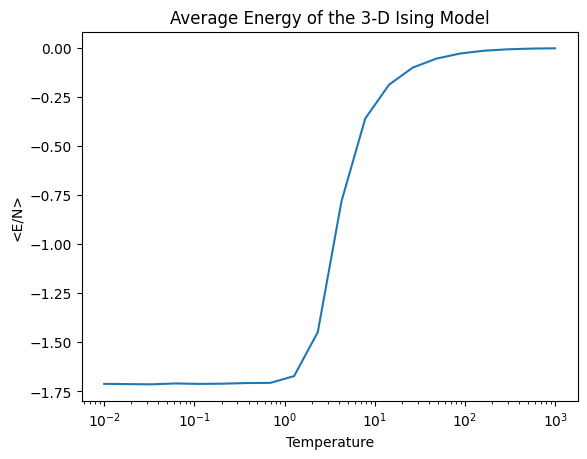

In [19]:
#Plot <E/N>(T)
plt.plot(Temps,E_T, label='Numerical Result')
plt.title("Average Energy of the 3-D Ising Model")
plt.xscale('log')
plt.xlabel("Temperature")
plt.ylabel("<E/N>")
#plt.savefig(f'Figures/3D/3D-Energy.jpg')
plt.show()

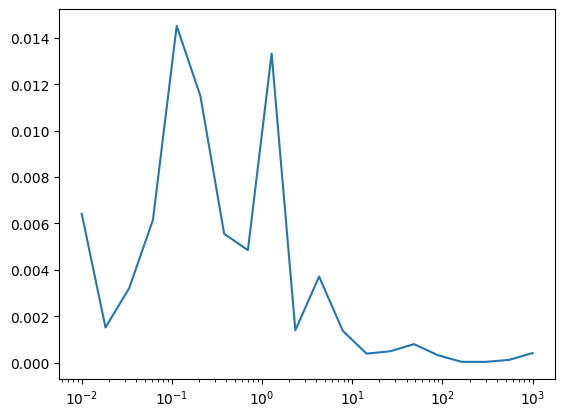

In [ ]:
#Plot <M>(T)
plt.plot(Temps,M_T)
#plt.xscale('log')
plt.show()

In [4]:
#Plot Spin Configurations
#for i_T in range(Nt):
 #   print(f'Temperature: {Temps[i_T]}')
 #   f,ax = plt.subplots(1,2)
 #   ax[0].imshow(s_T[i_T][0],cmap='gray')
 #   ax[0].set_xticks([]);
 #   ax[0].set_yticks([]);
 #  ax[0].xaxis.set_label_position('bottom')
 #   ax[0].set_xlabel('Initial State',fontsize=16)
 #  ax[1].imshow(s_T[i_T][1],cmap='gray')
 #   ax[1].set_xticks([]);
 #   ax[1].set_yticks([]);   
 #   ax[1].xaxis.set_label_position('bottom')
 #   ax[1].set_xlabel('Final State',fontsize=16)
 #   f.suptitle(f'T = {Temps[i_T]:.4f}',y=.85,fontsize=16)
 #   plt.tight_layout()
 #   #plt.savefig(f'Figures/3D/3D-spinconfigplots/3Dconfig{i_T+1}.jpg')
 #   plt.show()

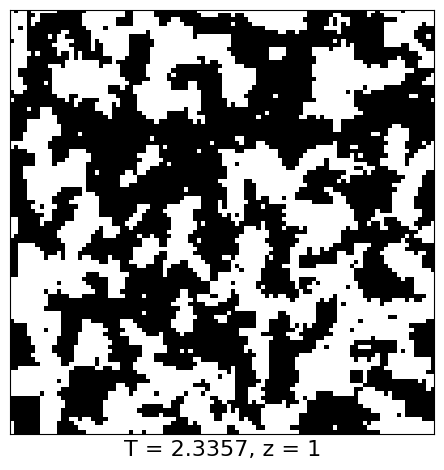

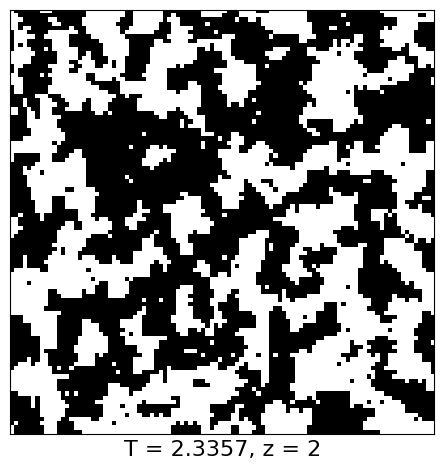

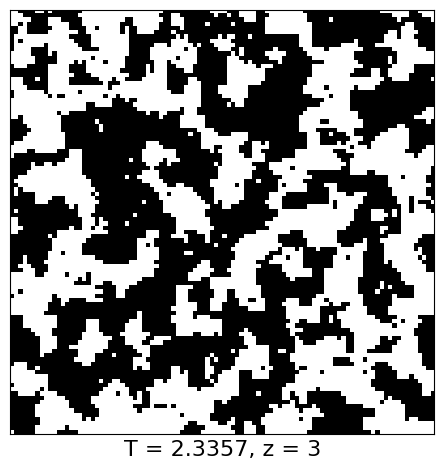

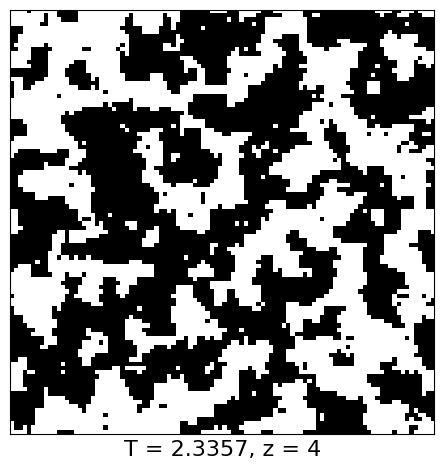

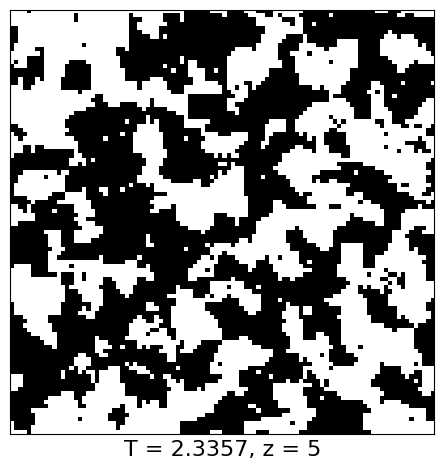

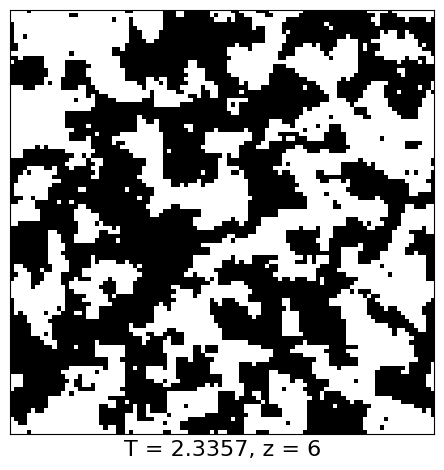

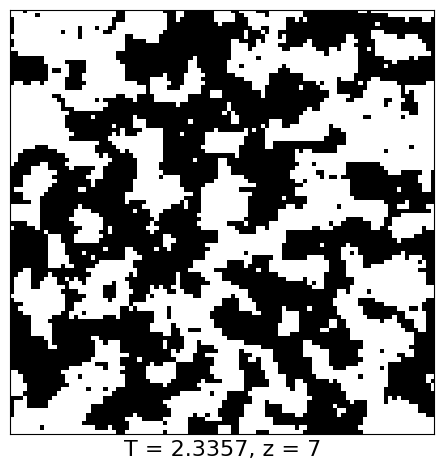

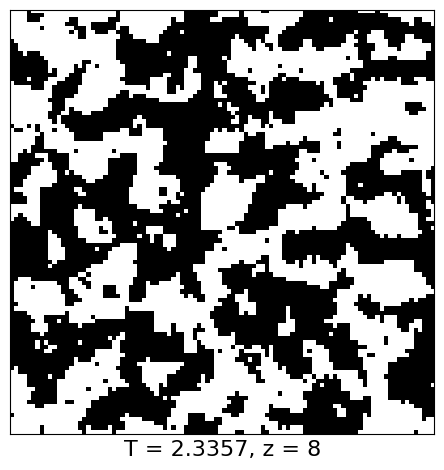

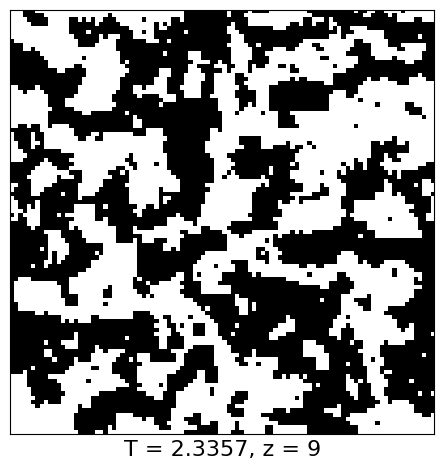

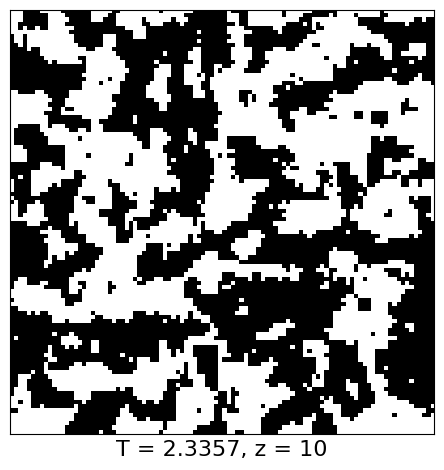

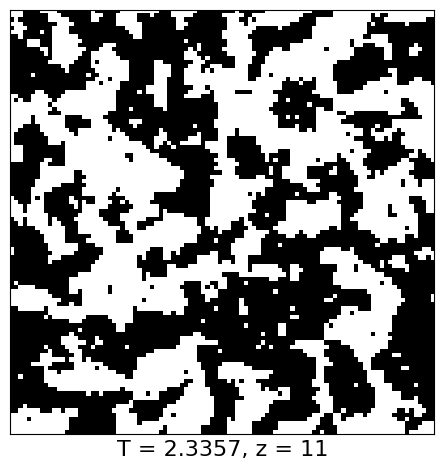

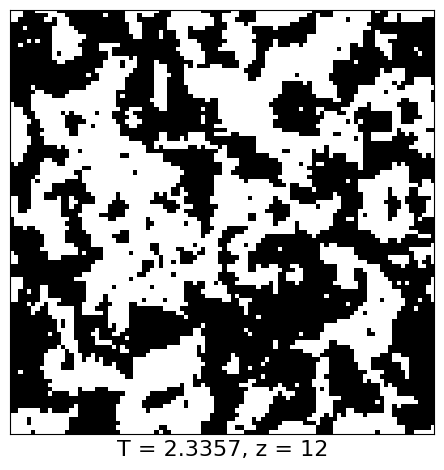

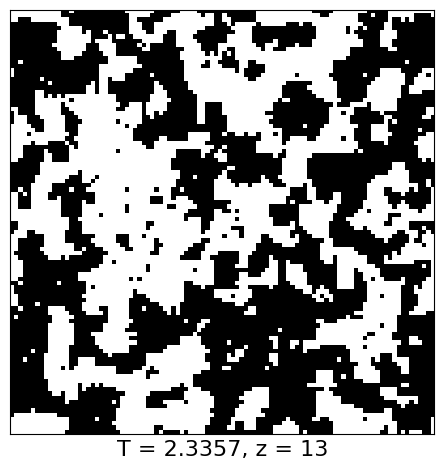

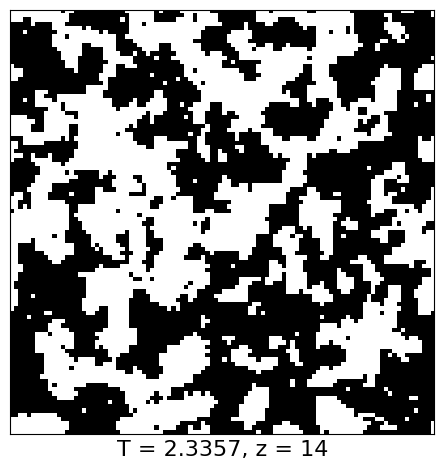

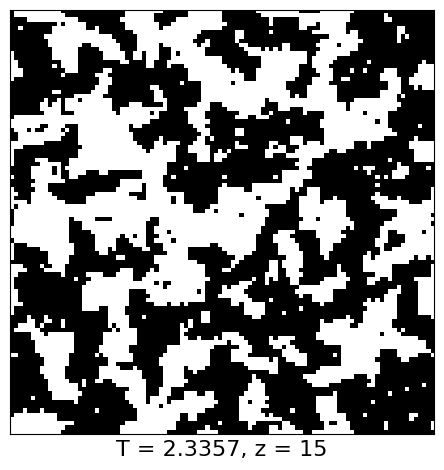

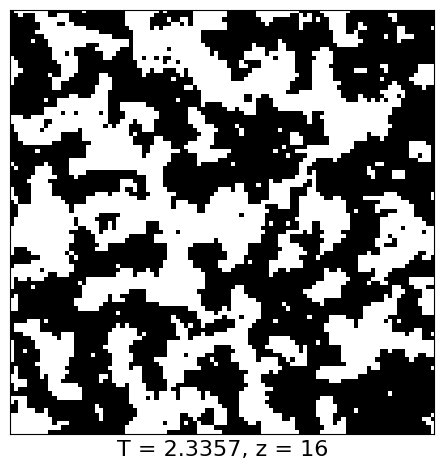

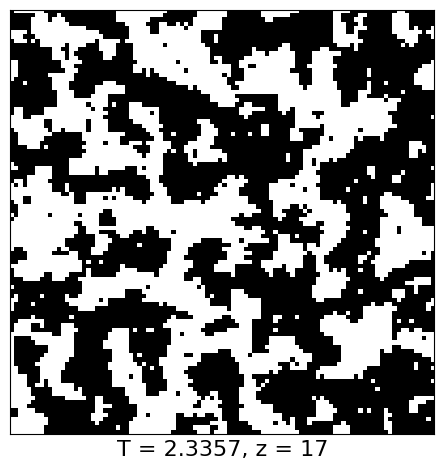

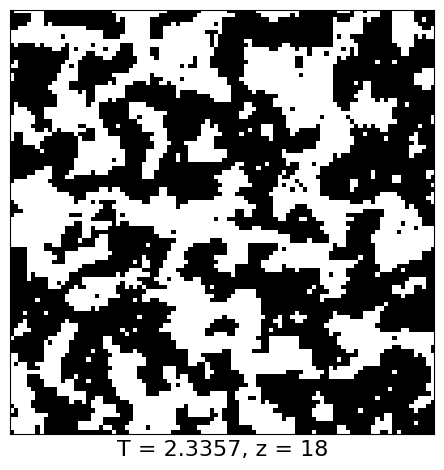

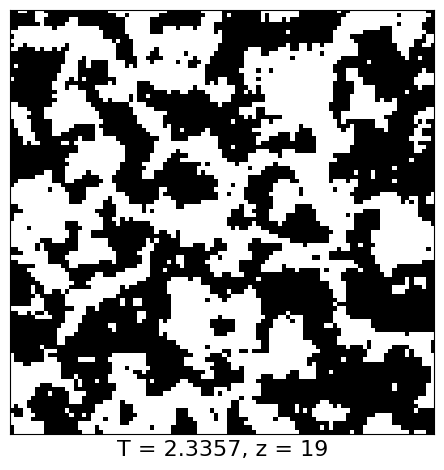

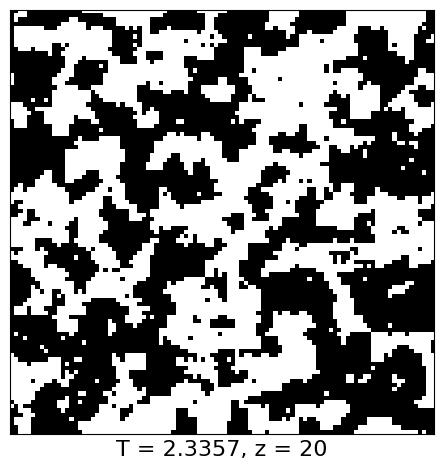

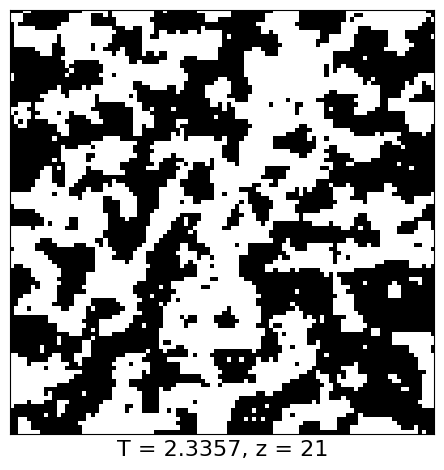

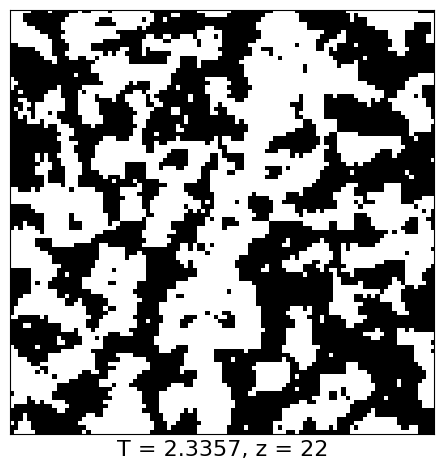

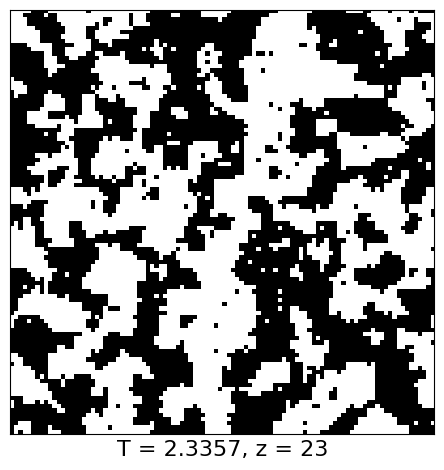

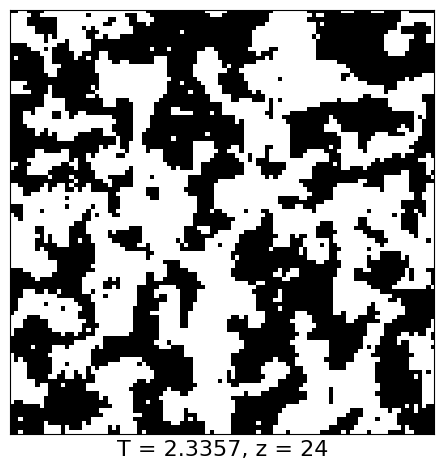

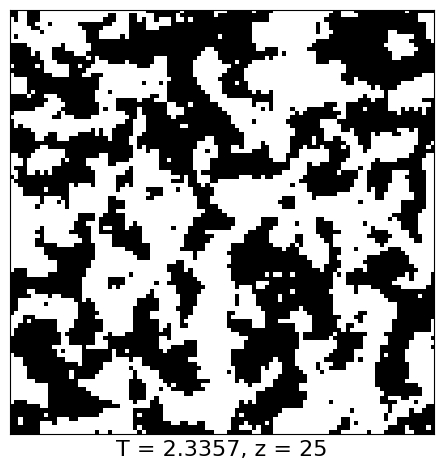

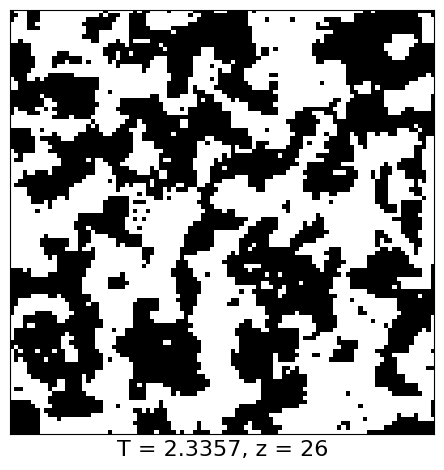

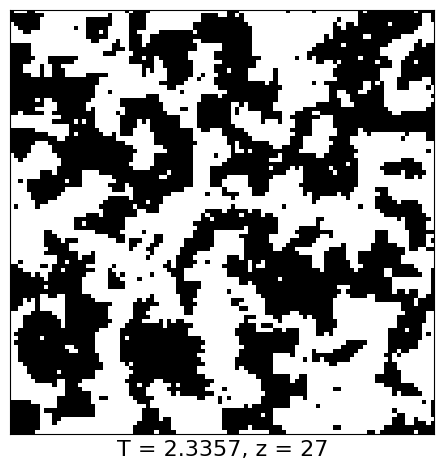

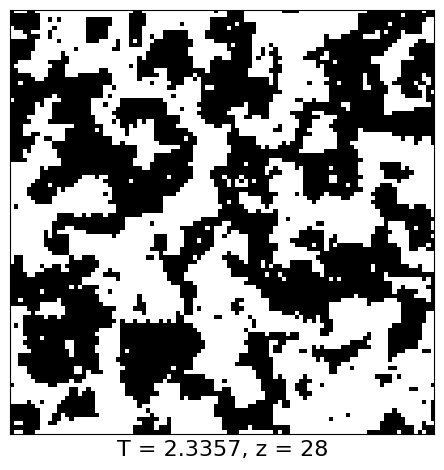

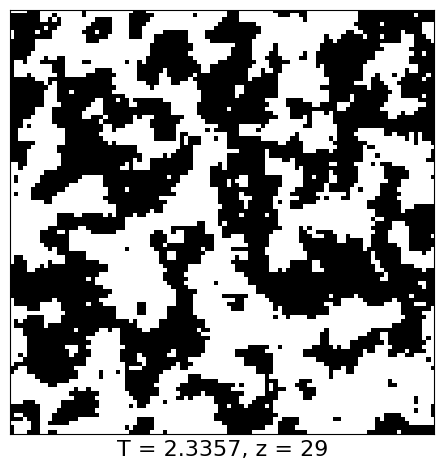

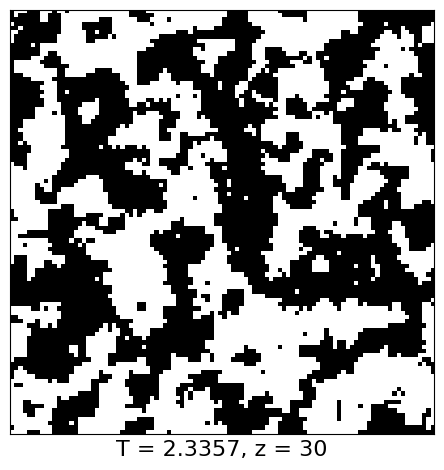

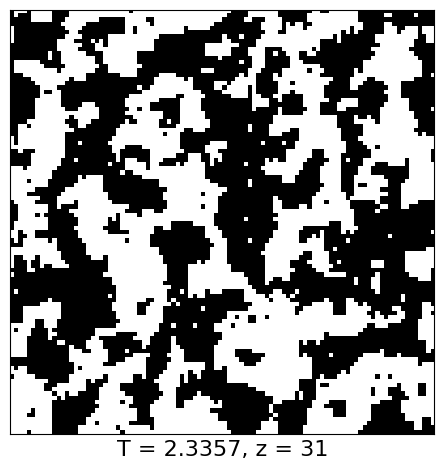

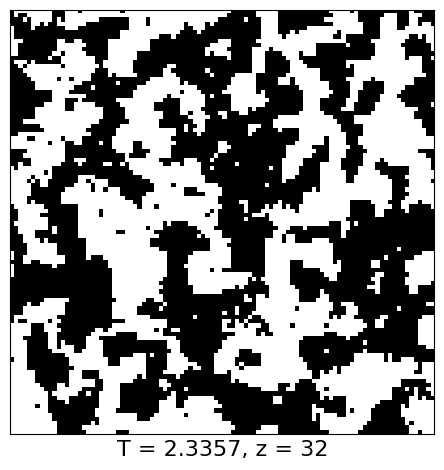

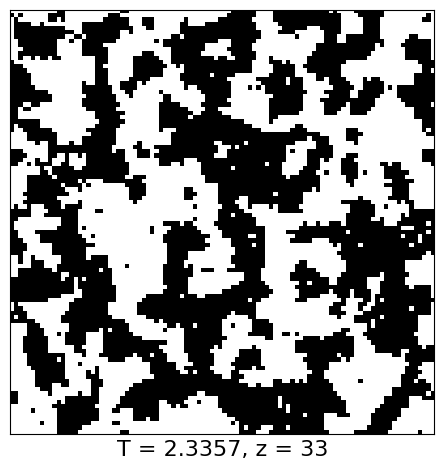

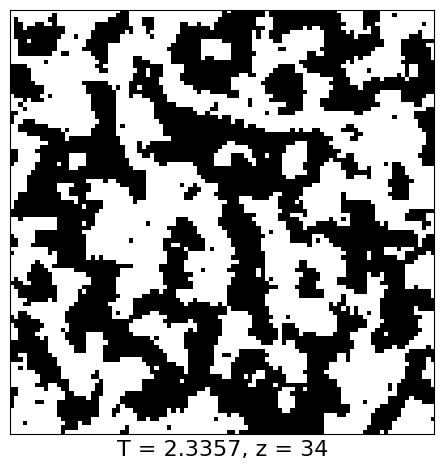

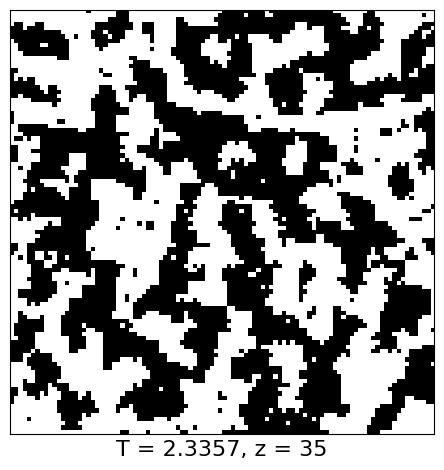

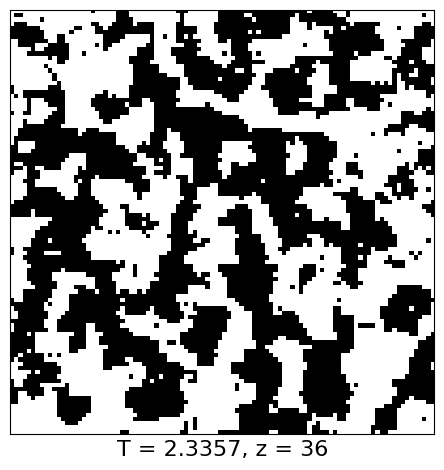

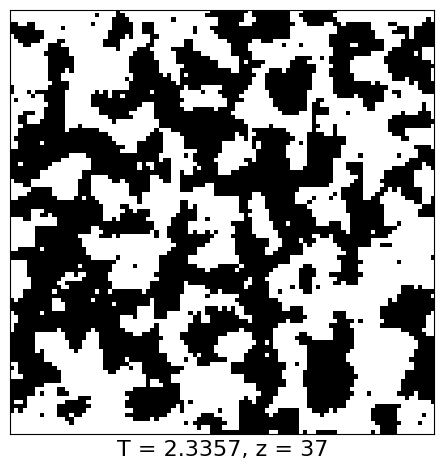

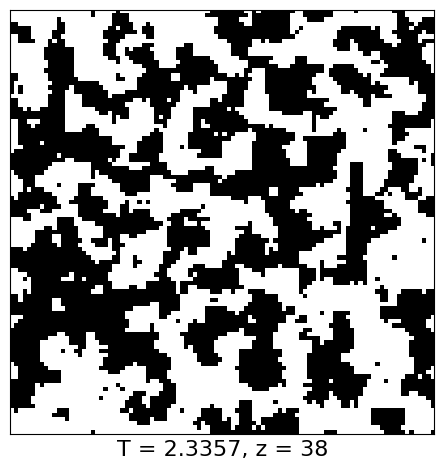

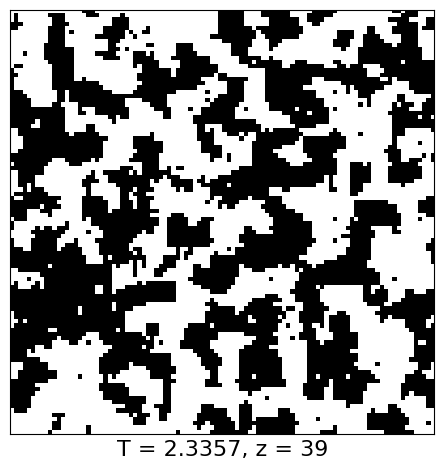

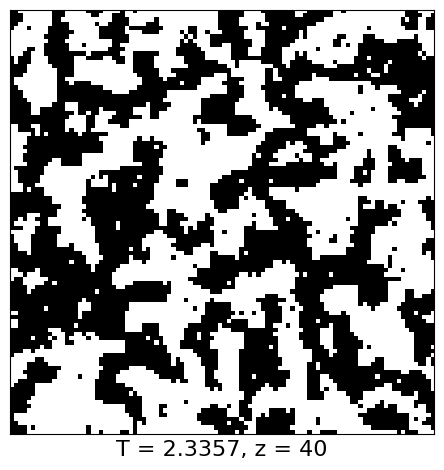

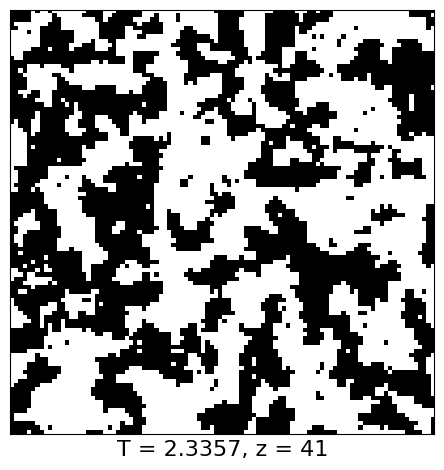

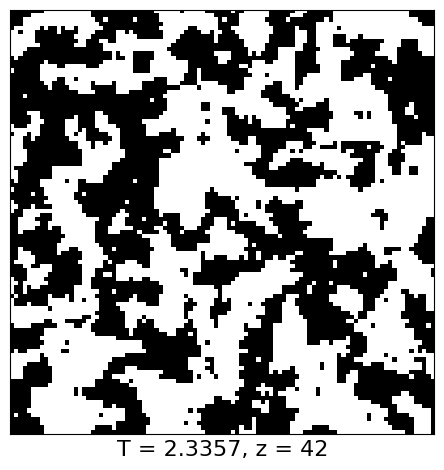

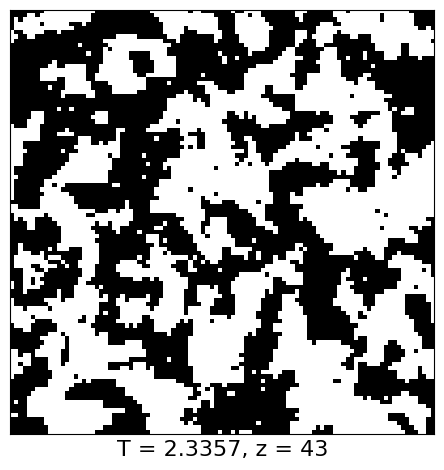

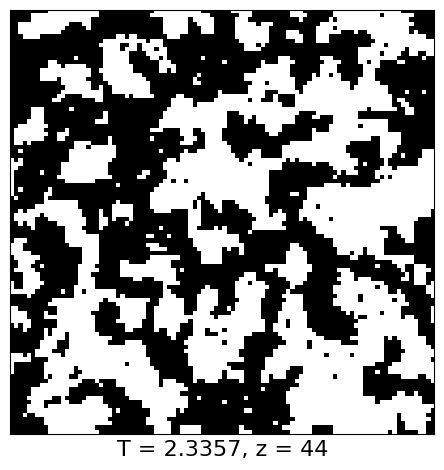

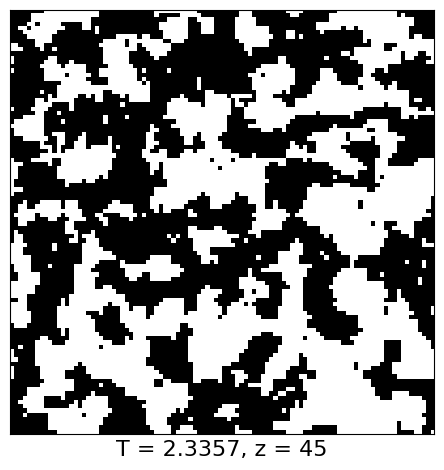

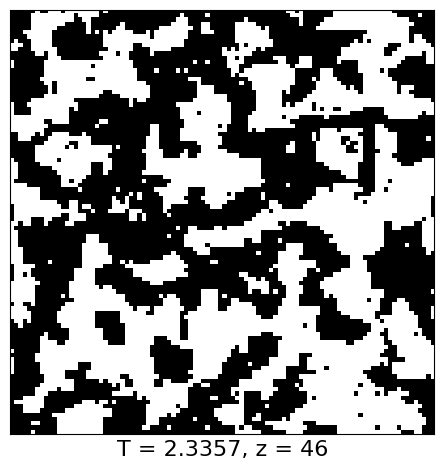

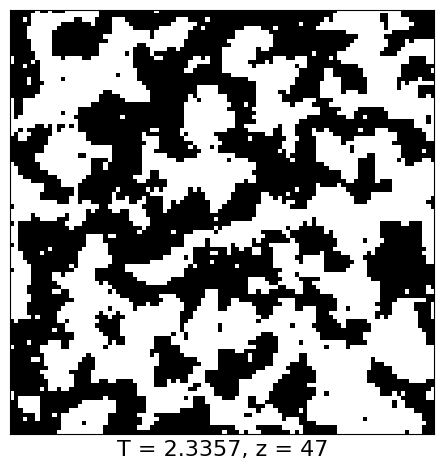

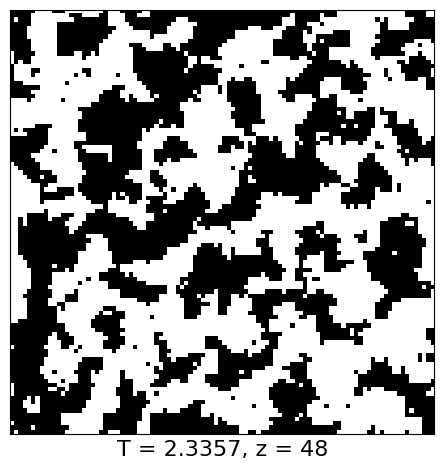

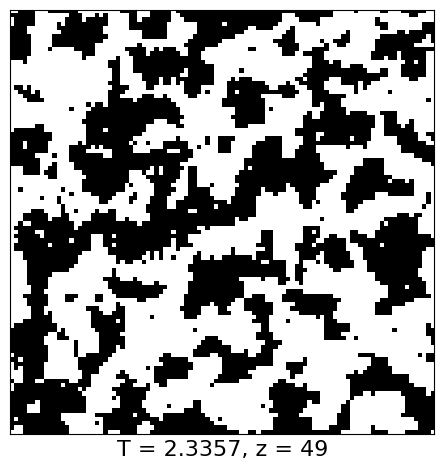

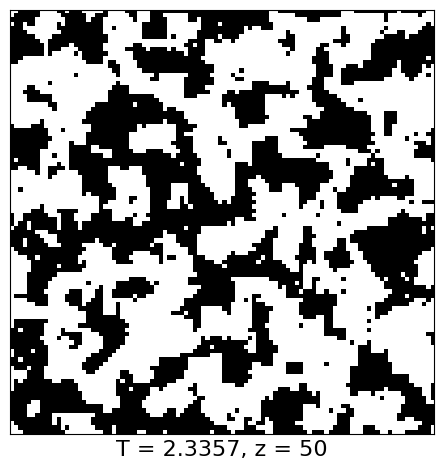

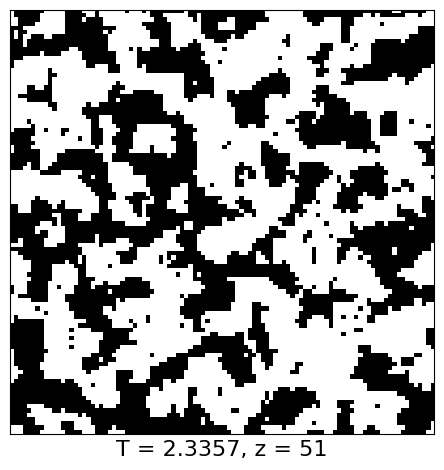

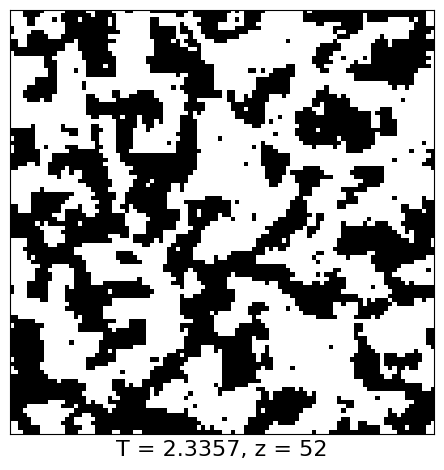

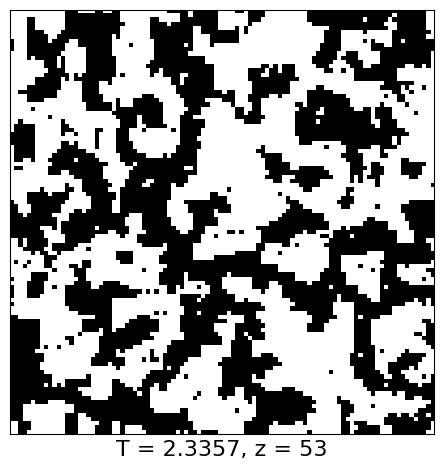

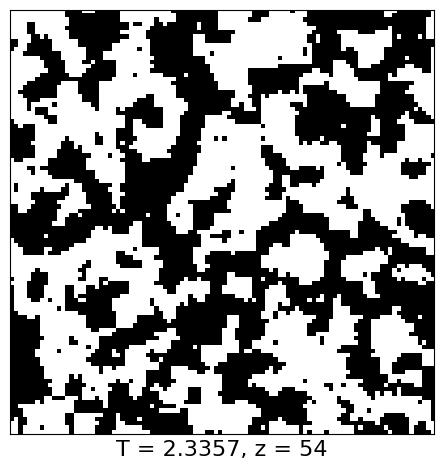

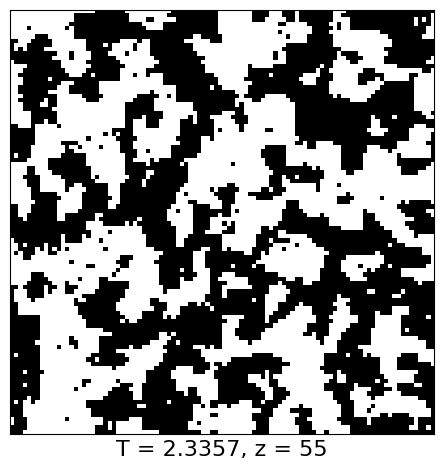

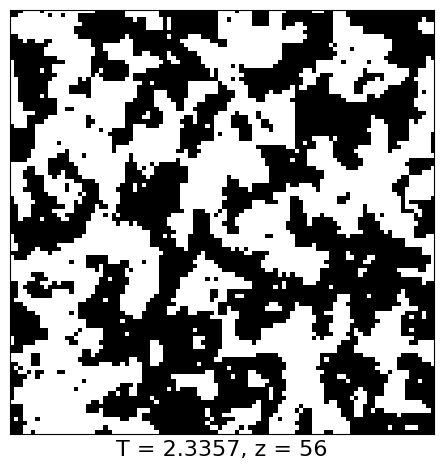

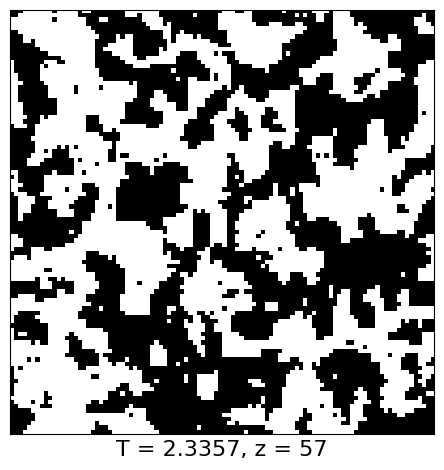

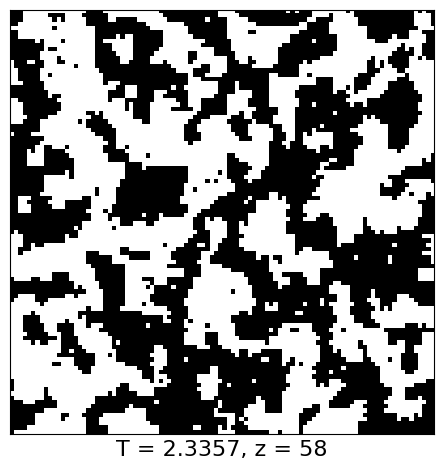

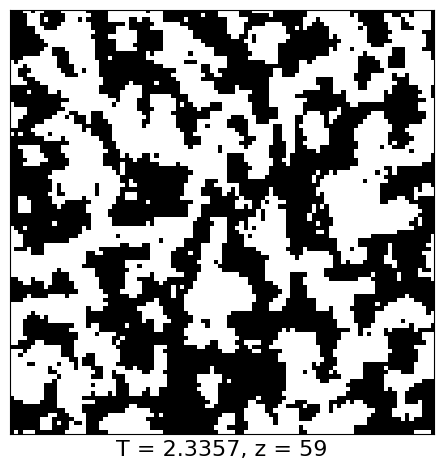

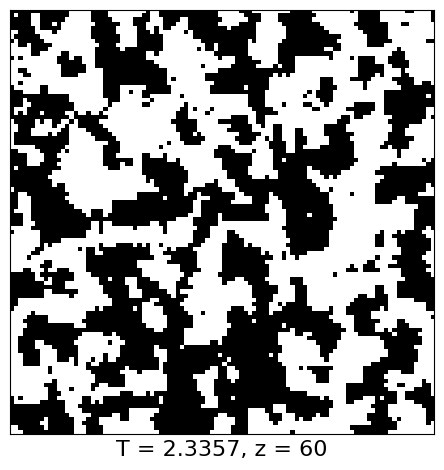

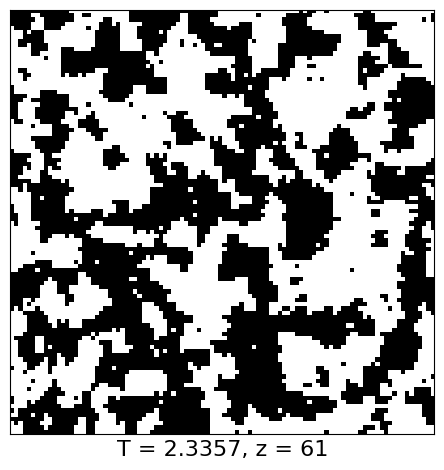

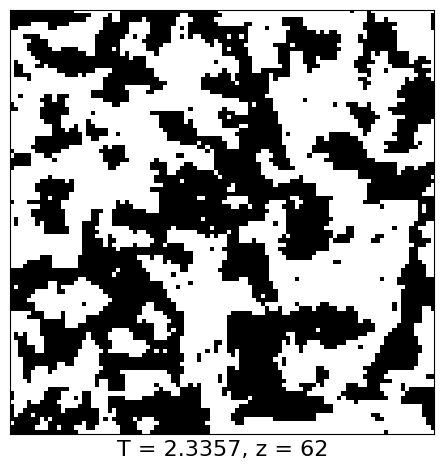

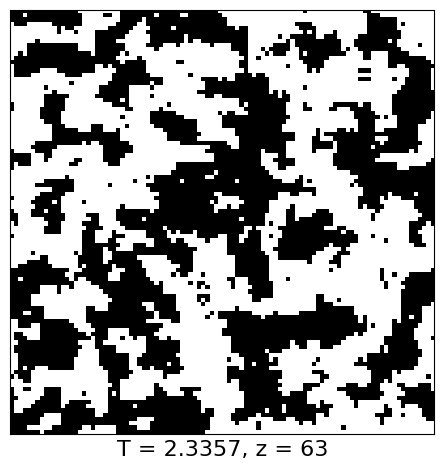

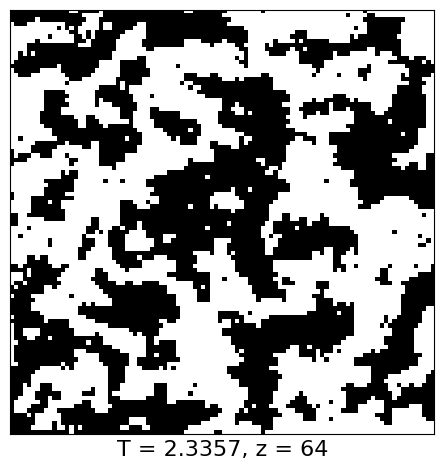

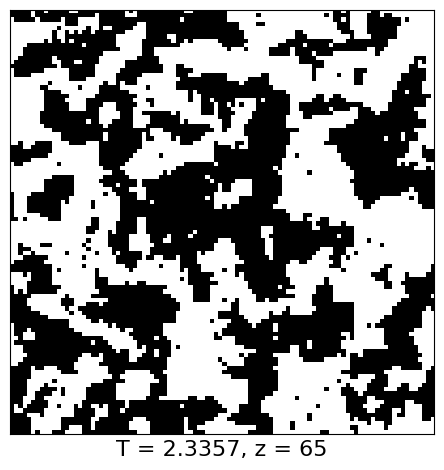

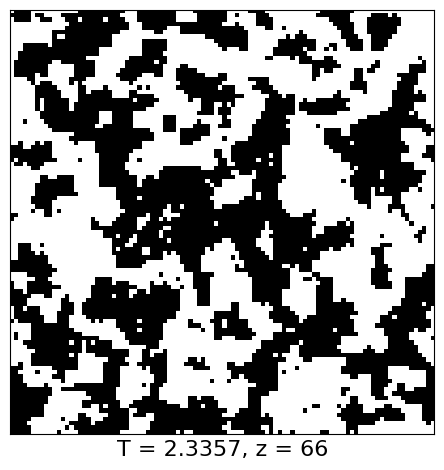

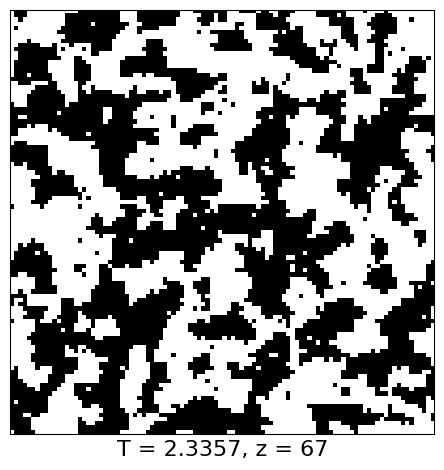

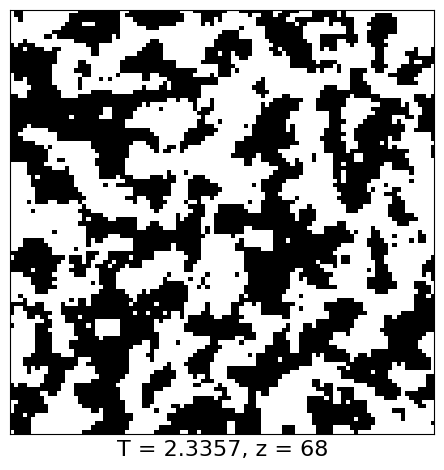

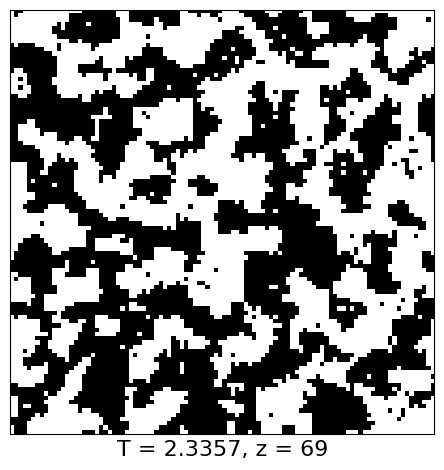

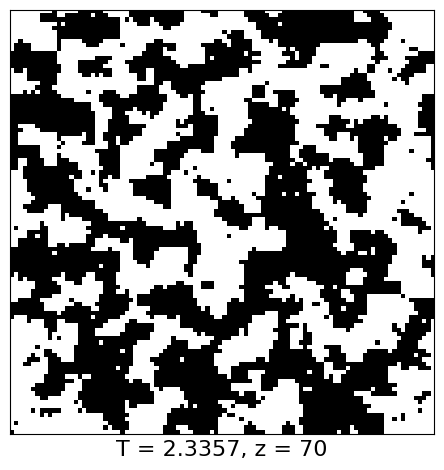

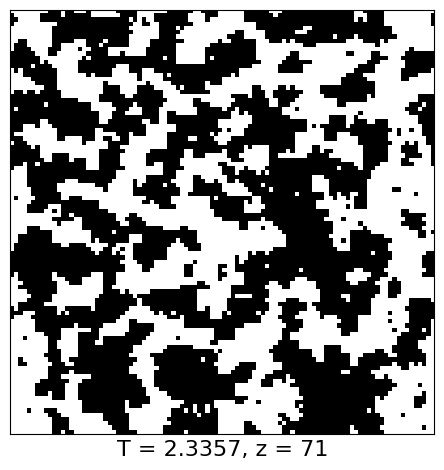

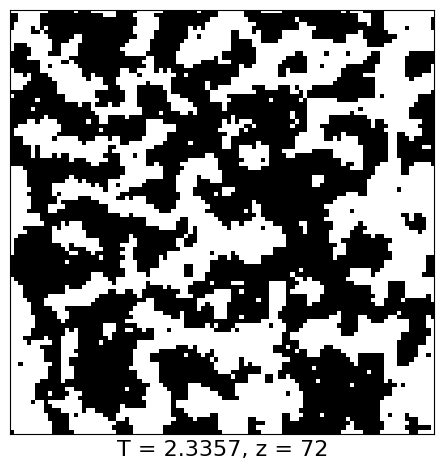

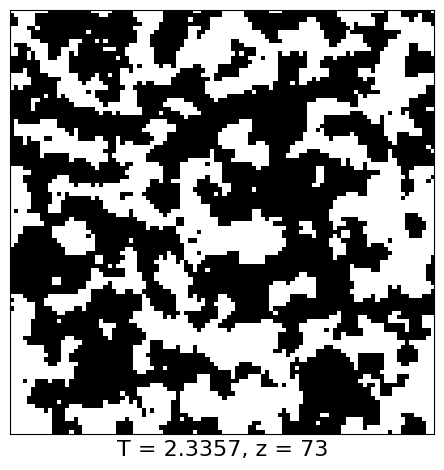

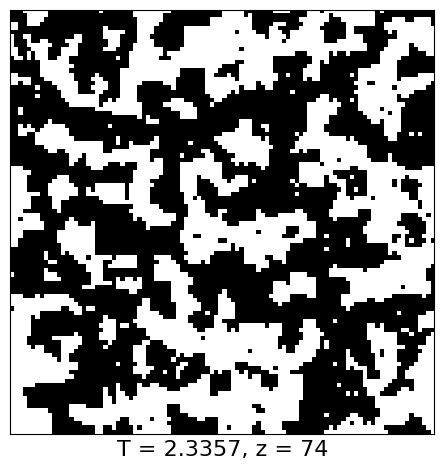

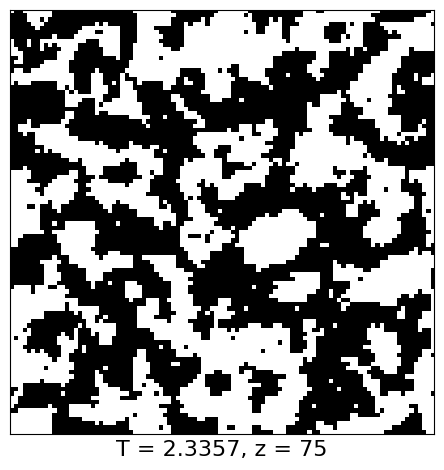

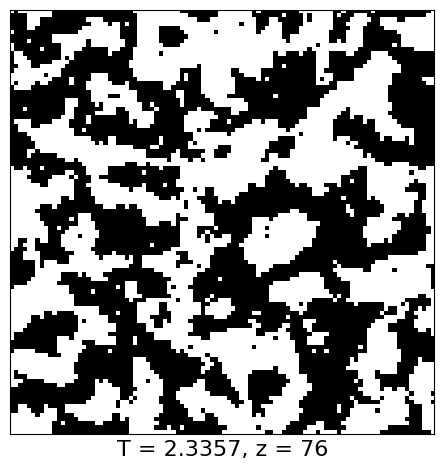

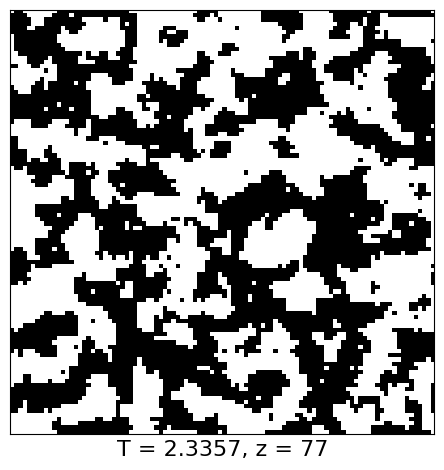

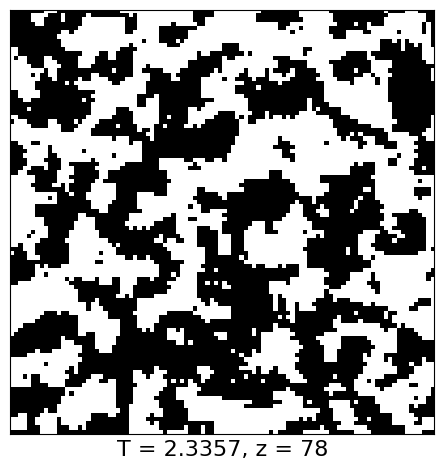

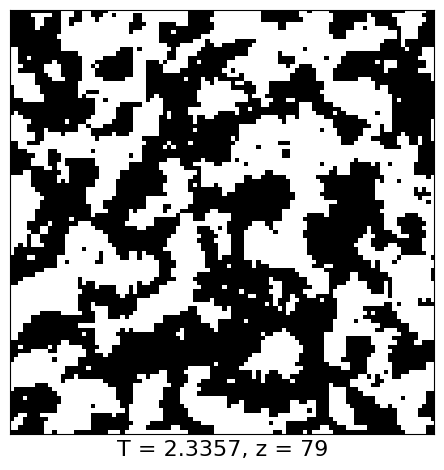

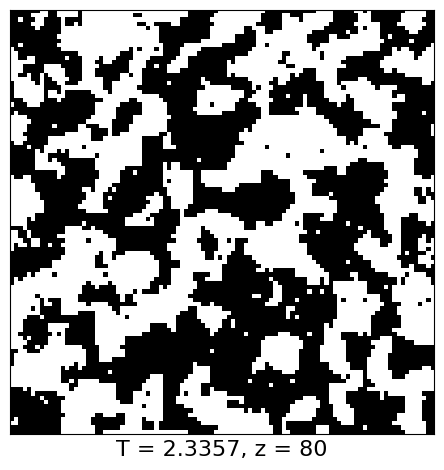

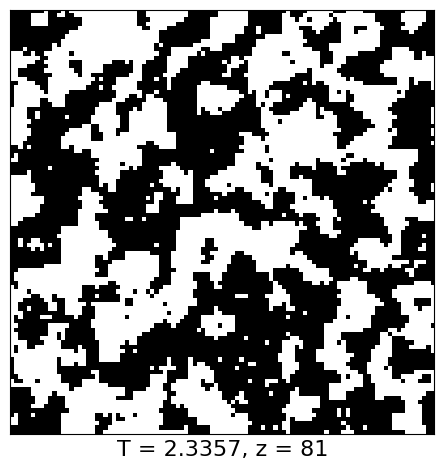

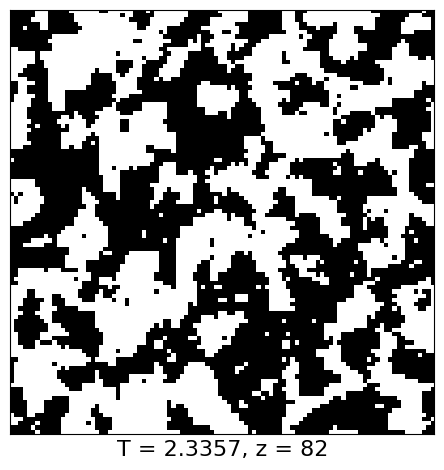

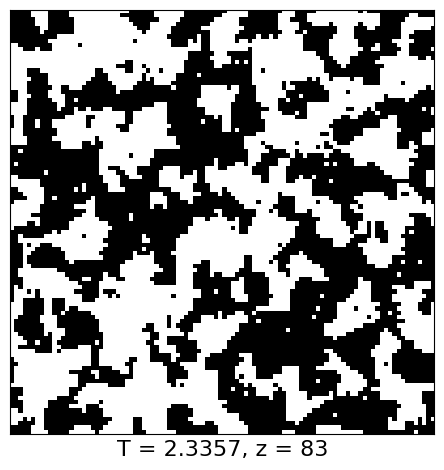

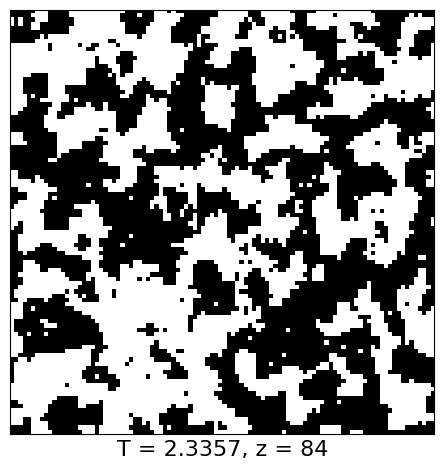

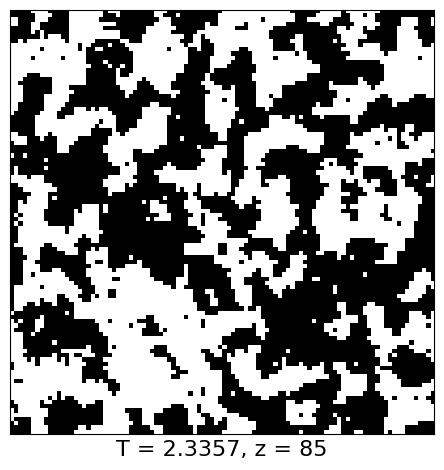

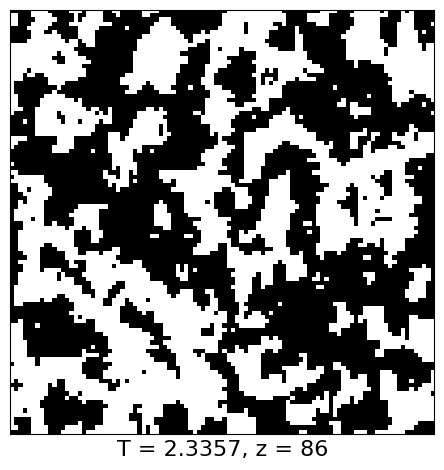

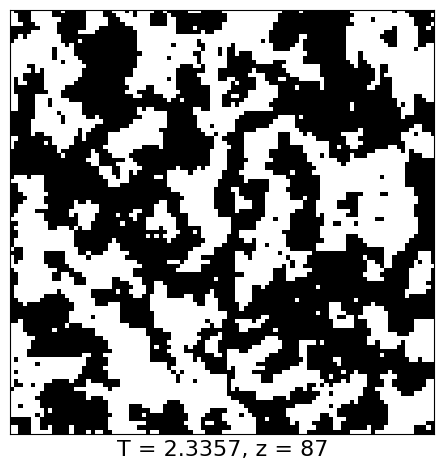

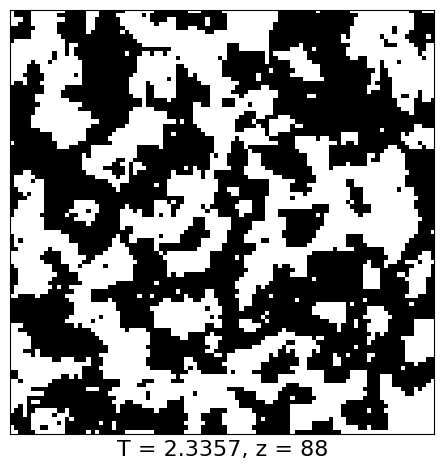

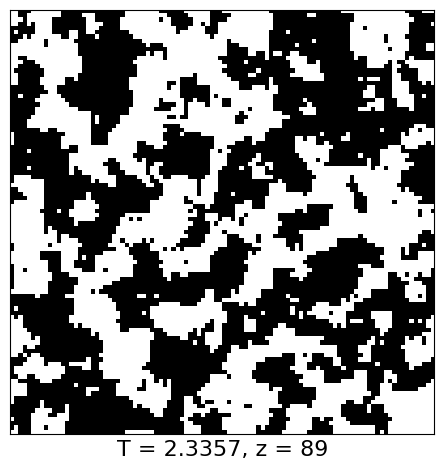

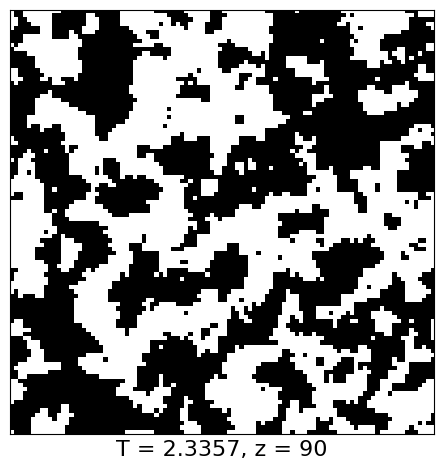

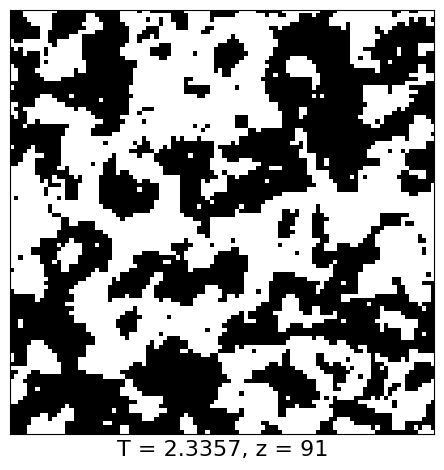

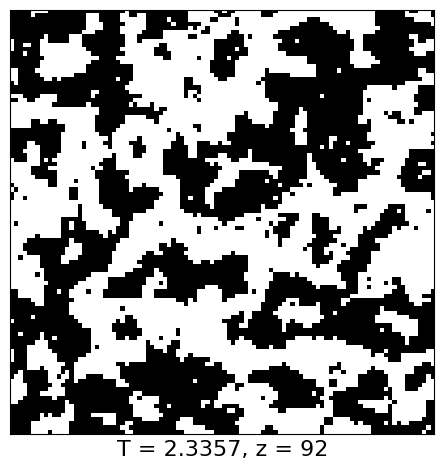

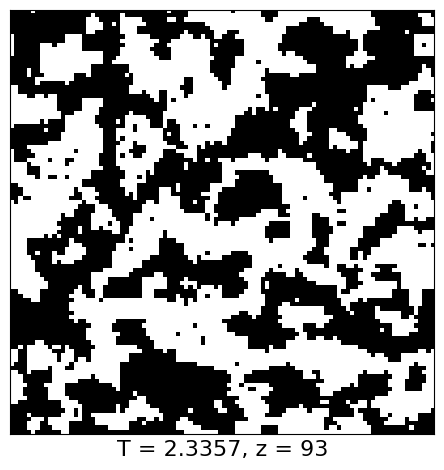

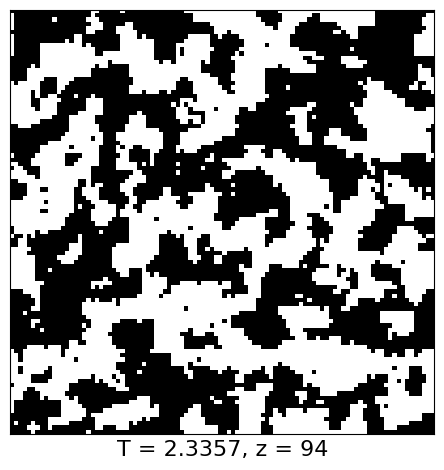

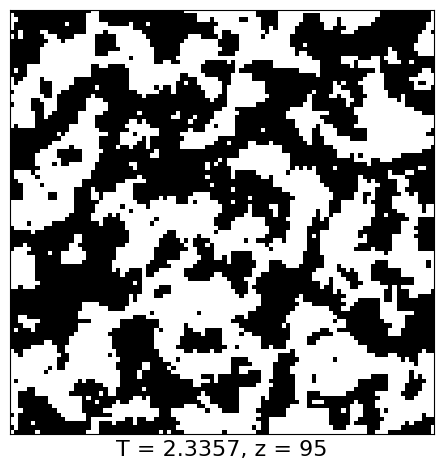

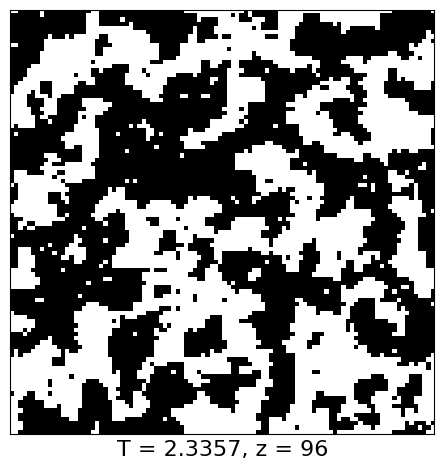

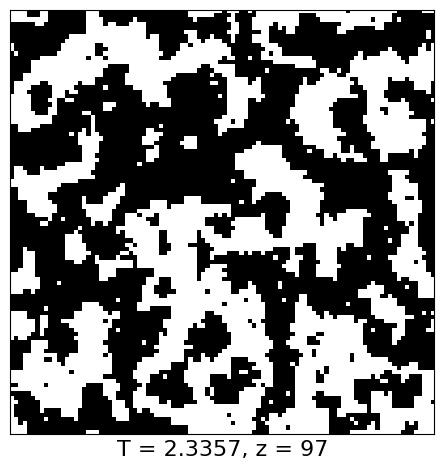

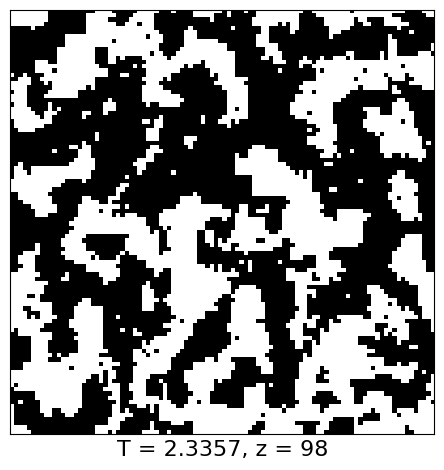

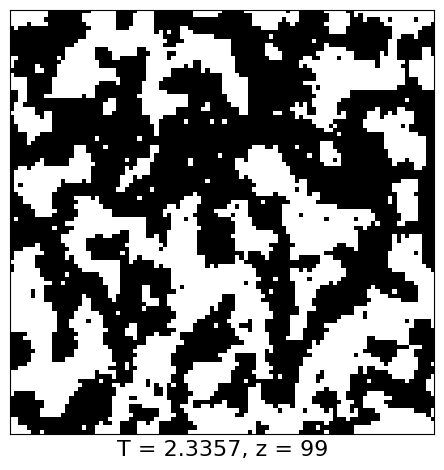

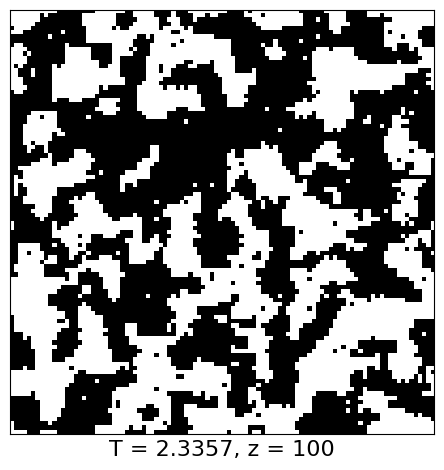

In [16]:
#Plot Spin Configuration Slices
i_T = 9
for zslice in range(L):
    plt.imshow(s_T[i_T][1][:,:,zslice],cmap='gray')
    plt.xticks([]);
    plt.yticks([]);
    plt.xlabel(f'T = {Temps[i_T]:.4f}, z = {zslice+1}',fontsize=16)
    plt.tight_layout()
    #plt.savefig(f'Figures/3D/3D-spinconfigplots/3Dconfig{i_T+1}.jpg')
    plt.show()